# SPOmiAlign Demo: Image to Image Section Alignment

This notebook follows a fixed workflow:
1. Input unaligned slices (paired images)
2. Imaging (generation of spatial structural images, SSI)
3. Sections matching and warpping
4. Reassignment
5. Output aligned slices

This version fixes the reassignment roles explicitly:
- `S1 / aligned SM = high resolution`
- `S2 / reference ST = low resolution`


## 1. Input unaligned slices (paired images)

In [1]:
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial import cKDTree



NOTEBOOK_DIR = Path().resolve()
DEMO_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = DEMO_DIR.parent
print(PROJECT_ROOT)
sys.path.append(str(PROJECT_ROOT / "SPOmiAlign"))

from data_preprocessing import scatter_h5ad_to_image
from reassignment_direction import (
    build_reassigned_h5ad_from_mapping,
    cmap_blue,
    cmap_orange,
    get_spatial_from_adata,
    mean_internal_nn_distance,
    plot_h5ad_umi_squares,
)
from roma import align_and_process_images


def _first_existing_path(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def _read_image(image_path):
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f"Failed to read image: {image_path}")
    return image


def _fit_to_reference_canvas(reference_img, moving_img):
    ref_h, ref_w = reference_img.shape[:2]
    mov_h, mov_w = moving_img.shape[:2]
    canvas = np.full((ref_h, ref_w, 3), 255, dtype=np.uint8)
    canvas[: min(ref_h, mov_h), : min(ref_w, mov_w)] = moving_img[
        : min(ref_h, mov_h), : min(ref_w, mov_w)
    ]
    return canvas


def _blend_on_reference(reference_path, moving_path, out_path, alpha_reference=0.55, alpha_moving=0.45):
    reference_img = _read_image(reference_path)
    moving_img = _read_image(moving_path)
    moving_canvas = _fit_to_reference_canvas(reference_img, moving_img)
    overlay = cv2.addWeighted(reference_img, alpha_reference, moving_canvas, alpha_moving, 0)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out_path), overlay)
    return out_path


def _prepare_directional_inputs(st_h5ad_path, sm_h5ad_path, aligned_sm_h5ad_path, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)

    st_adata = sc.read_h5ad(str(st_h5ad_path))
    st_adata.obsm["spatial_raw"] = np.asarray(st_adata.obsm["spatial"]).copy()
    st_with_keys_path = out_dir / "st_with_reference_keys.h5ad"
    st_adata.write_h5ad(str(st_with_keys_path), compression="gzip")

    sm_raw_adata = sc.read_h5ad(str(sm_h5ad_path))
    sm_aligned_adata = sc.read_h5ad(str(aligned_sm_h5ad_path))
    raw_xy = np.asarray(sm_raw_adata.obsm["spatial"]).copy()
    aligned_xy = np.asarray(sm_aligned_adata.obsm["spatial"]).copy()

    if raw_xy.shape[0] != aligned_xy.shape[0]:
        raise ValueError("The original SM and aligned SM H5AD files do not have the same number of spots.")

    sm_aligned_adata.obsm["spatial_raw"] = raw_xy
    sm_aligned_adata.obsm["spatial_spomialign"] = aligned_xy.copy()
    sm_aligned_adata.obsm["spatial"] = aligned_xy.copy()
    sm_with_keys_path = out_dir / "sm_with_spomialign.h5ad"
    sm_aligned_adata.write_h5ad(str(sm_with_keys_path), compression="gzip")

    return st_with_keys_path, sm_with_keys_path


def _run_directional_reassignment_fixed_roles(s1_h5ad, s2_h5ad, direction, out_dir, plot_dir, s1_spatial_key, s2_spatial_key):
    out_dir.mkdir(parents=True, exist_ok=True)
    plot_dir.mkdir(parents=True, exist_ok=True)

    adata_s1 = sc.read_h5ad(str(s1_h5ad))
    adata_s2 = sc.read_h5ad(str(s2_h5ad))

    high_xy = get_spatial_from_adata(adata_s1, s1_spatial_key)
    low_xy = get_spatial_from_adata(adata_s2, s2_spatial_key)

    def _clean_xy(xy):
        mask = np.isfinite(xy).all(axis=1)
        return xy[mask, :], mask

    high_xy_clean, high_mask = _clean_xy(high_xy)
    low_xy_clean, low_mask = _clean_xy(low_xy)

    if high_xy_clean.shape[0] == 0 or low_xy_clean.shape[0] == 0:
        raise ValueError("S1 or S2 has no valid coordinates after filtering.")

    mean_high, _ = mean_internal_nn_distance(high_xy_clean)
    mean_low, nn_low = mean_internal_nn_distance(low_xy_clean)
    d_ref_max = float(np.max(nn_low)) if nn_low.size > 0 else 0.0

    print(f"Using fixed roles for {direction}:")
    print("  S1 / aligned SM = high resolution")
    print("  S2 / reference ST = low resolution")
    print(f"  S1 valid spots: {high_xy_clean.shape[0]} / {high_xy.shape[0]}")
    print(f"  S2 valid spots: {low_xy_clean.shape[0]} / {low_xy.shape[0]}")
    print(f"  S1 mean NN distance: {mean_high:.4f}")
    print(f"  S2 mean NN distance: {mean_low:.4f}")
    print(f"  Low-resolution d_ref_max: {d_ref_max:.4f}")

    high_indices_all = np.where(high_mask)[0]
    low_indices_all = np.where(low_mask)[0]

    tree_low = cKDTree(low_xy_clean)
    dist, idx = tree_low.query(high_xy_clean, k=1)
    valid = dist <= 2.0 * d_ref_max if d_ref_max > 0 else np.ones_like(dist, dtype=bool)
    print(f"  Filtered out high-resolution spots: {int(np.sum(~valid))}")

    high_idx_clean = high_indices_all[valid]
    low_idx_clean = low_indices_all[idx[valid]]
    dist_f = dist[valid]

    if direction == "high_to_low":
        mapping = pd.DataFrame(
            {
                "source_index": high_idx_clean,
                "target_index": low_idx_clean,
                "source_x": high_xy_clean[valid][:, 0],
                "source_y": high_xy_clean[valid][:, 1],
                "target_x": low_xy_clean[idx[valid]][:, 0],
                "target_y": low_xy_clean[idx[valid]][:, 1],
                "distance": dist_f,
            }
        )
        out_h5ad = out_dir / "reassigned_high_to_low_on_st.h5ad"
        reassigned_cmap = cmap_orange
    elif direction == "low_to_high":
        mapping = pd.DataFrame(
            {
                "source_index": low_idx_clean,
                "target_index": high_idx_clean,
                "source_x": low_xy_clean[idx[valid]][:, 0],
                "source_y": low_xy_clean[idx[valid]][:, 1],
                "target_x": high_xy_clean[valid][:, 0],
                "target_y": high_xy_clean[valid][:, 1],
                "distance": dist_f,
            }
        )
        out_h5ad = out_dir / "reassigned_low_to_high_on_sm.h5ad"
        reassigned_cmap = cmap_blue
    else:
        raise ValueError("direction must be 'high_to_low' or 'low_to_high'.")

    print(mapping.head())

    meta = {
        "low_res_name": "S2",
        "high_res_name": "S1",
        "d_ref_max": d_ref_max,
        "reassignment_direction": direction,
        "s1_spatial_key": s1_spatial_key,
        "s2_spatial_key": s2_spatial_key,
    }

    map_csv = out_dir / f"{direction}_mapping.csv"
    mapping.to_csv(map_csv, index=False)

    plot_h5ad_umi_squares(
        adata_s1,
        out_png=str(plot_dir / "S1_umi.png"),
        title=f"S1 UMI ({s1_spatial_key})",
        spatial_key=s1_spatial_key,
        cmap=cmap_orange,
    )
    plot_h5ad_umi_squares(
        adata_s2,
        out_png=str(plot_dir / "S2_umi.png"),
        title=f"S2 UMI ({s2_spatial_key})",
        spatial_key=s2_spatial_key,
        cmap=cmap_blue,
    )

    adata_new = build_reassigned_h5ad_from_mapping(
        mapping=mapping,
        meta=meta,
        adata_s1=adata_s1,
        adata_s2=adata_s2,
        out_h5ad=str(out_h5ad),
        scale_by_mapping_factor=True,
        reserved_col=None,
    )

    plot_h5ad_umi_squares(
        adata_new,
        out_png=str(plot_dir / f"reassigned_{direction}_umi.png"),
        title=f"Reassigned ({direction}) UMI",
        spatial_key="spatial",
        cmap=reassigned_cmap,
    )

    return out_h5ad, map_csv, meta


def _label_for_dataset(dataset_name):
    if dataset_name == "S1":
        return "S1: aligned SM"
    if dataset_name == "S2":
        return "S2: reference ST"
    return dataset_name


def _show_bgr(ax, image_path, title):
    image = _read_image(image_path)
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")


DATA_DIR = Path(
    os.environ.get("SPOMIALIGN_DEMO_DATA_DIR", DEMO_DIR / "SPOmiAlign_Repro")
).expanduser()
SAVE_DIR = Path(
    os.environ.get("SPOMIALIGN_DEMO_SAVE_DIR", DEMO_DIR / "output")
).expanduser()
SAVE_PATH = SAVE_DIR / "h5ad_2_h5ad/sm2st1"
SAVE_PATH.mkdir(parents=True, exist_ok=True)

st_candidates = [
    DATA_DIR / "output_h5ad" / "st_withIntensity.h5ad",
    DATA_DIR / "st_withIntensity.h5ad",
    DATA_DIR / "st.h5ad",
]
sm_candidates = [
    DATA_DIR / "output_h5ad" / "sm_withIntensity.h5ad",
    DATA_DIR / "sm_withIntensity.h5ad",
    DATA_DIR / "sm.h5ad",
]

h5ad_img1_path = _first_existing_path(st_candidates)
h5ad_img2_path = _first_existing_path(sm_candidates)
assert h5ad_img1_path is not None, f"Target ST H5AD not found. Checked: {st_candidates}"
assert h5ad_img2_path is not None, f"Source SM H5AD not found. Checked: {sm_candidates}"

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {SAVE_PATH}")
print(f"Target ST H5AD: {h5ad_img1_path}")
print(f"Source SM H5AD: {h5ad_img2_path}")


/storage/hermes/yiwang/spomialign/SPOmiAlign-main
Data directory: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro
Output directory: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/sm2st1
Target ST H5AD: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_h5ad/st_withIntensity.h5ad
Source SM H5AD: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_h5ad/sm_withIntensity.h5ad


## 2. Imaging (generation of spatial structural images, SSI)

[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/sm2st1/st_scatter.png (2200x2199, background=white, shape=square, points=1677)
[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/sm2st1/sm_scatter.png (2186x2200, background=white, shape=square, points=3908)


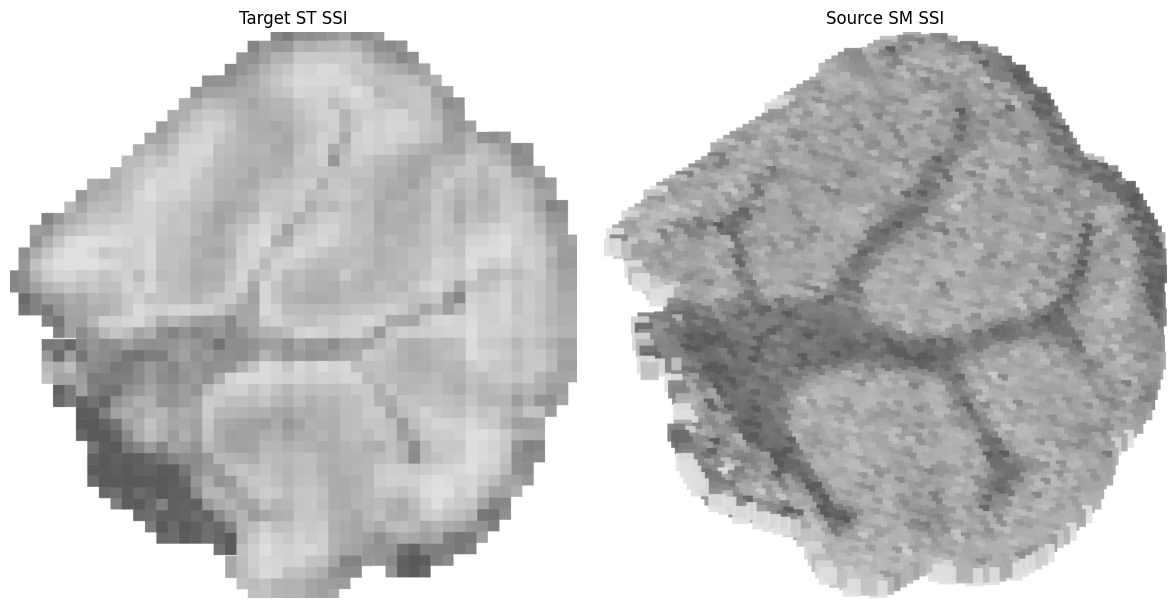

In [2]:
%matplotlib inline
Gen_img1_path = SAVE_PATH / "st_scatter.png"
Gen_img2_path = SAVE_PATH / "sm_scatter.png"

scatter_h5ad_to_image(
    input_h5ad=str(h5ad_img1_path),
    output_png=str(Gen_img1_path),
    background="white",
    point_shape="square",
    radius=15,
    threshold_percentile=None,
    intensity_log_transform=False,
    rotate=0.0,
    scale=1.0,
    display_long_side=2200,
    padding=32,
    dpi=200,
    marker_alpha=0.9,
    gray_min=0.35,
    gray_max=0.88,
)

_, origin = scatter_h5ad_to_image(
    input_h5ad=str(h5ad_img2_path),
    output_png=str(Gen_img2_path),
    background="white",
    point_shape="square",
    radius=12,
    threshold_percentile=None,
    intensity_log_transform=False,
    rotate=60.0,
    scale=0.6,
    display_long_side=2200,
    padding=32,
    dpi=200,
    marker_alpha=0.9,
    gray_min=0.35,
    gray_max=0.88,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
_show_bgr(axes[0], Gen_img1_path, "Target ST SSI")
_show_bgr(axes[1], Gen_img2_path, "Source SM SSI")
plt.tight_layout()
plt.show()


## 3. Sections matching and warpping

Using device: cuda:0


2026-04-13 01:23:09.851 | INFO     | romatch.models.model_zoo.roma_models:roma_model:61 - Using coarse resolution (560, 560), and upsample res (864, 1152)


Running RoMa matching...
Estimating affine+bspline transform...
Warping images...
Padding fill color: (255, 255, 255)
Processing H5AD coordinates...
[OK] Step 00 source coordinates mapped to render space: 710/3908 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/sm2st1/alignment/debug_step_00_source_in_render_space.png
📝 Columns not found or not specified. Updating adata.obsm['spatial']
[OK] Step 02 after resize to registration grid (source resized canvas): 710/3908 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/sm2st1/alignment/debug_step_02_after_resize_to_registration.png
📝 Columns not found or not specified. Updating adata.obsm['spatial']
[OK] Step 03 after registration transform (target resized canvas): 745/3908 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/sm2st1/alignment/debug_step_03_after_registration_transform.png
[OK] Step 0

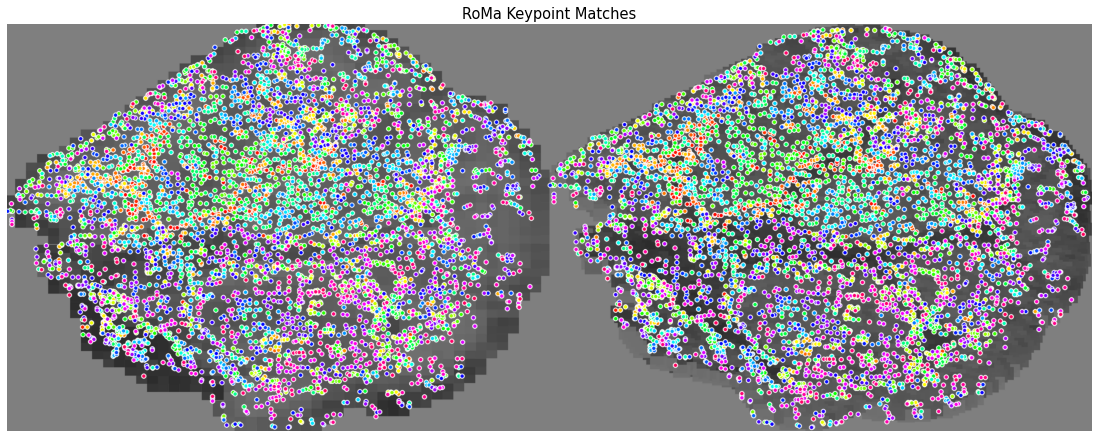

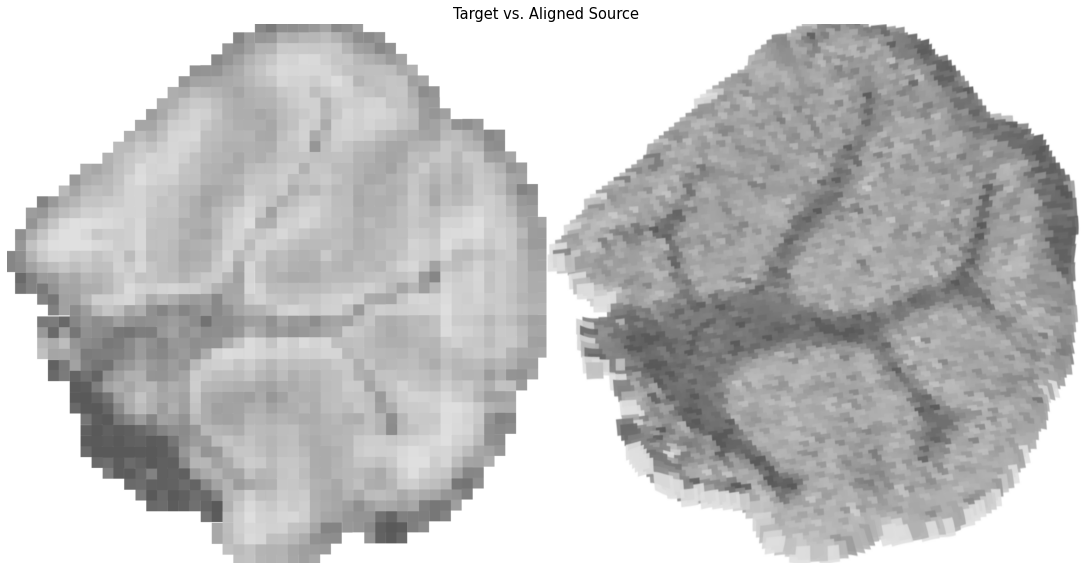

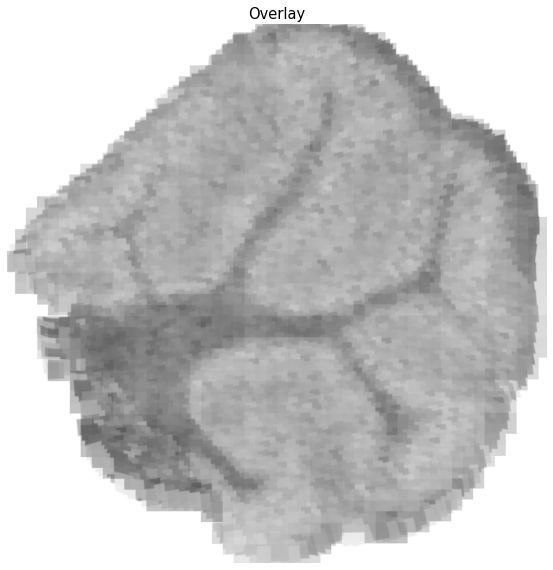

Alignment runtime: 6.2664 seconds
Done. Results saved to /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/sm2st1/alignment
[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_h5ad/sm2st1/alignment/transformed_h5ad_scatter.png (2200x2098, background=white, shape=square, points=3908)


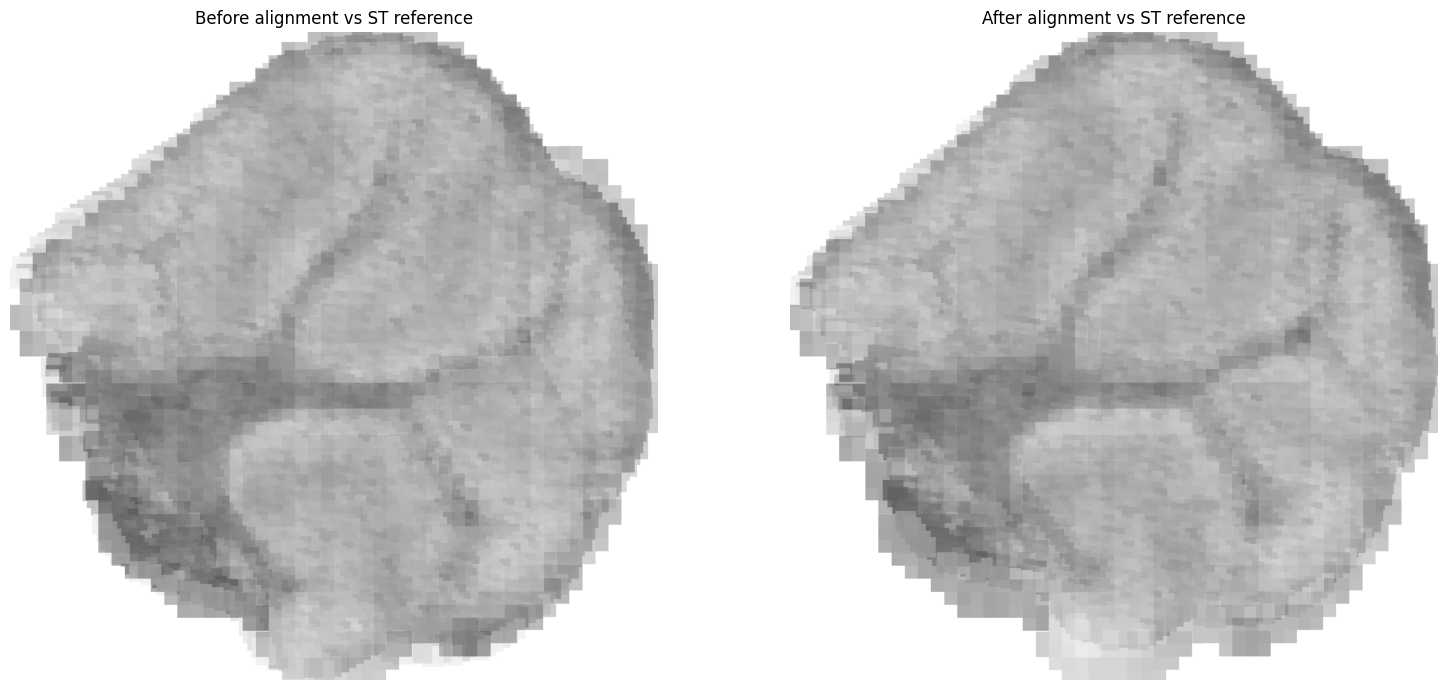

In [3]:
save_path_alignment = SAVE_PATH / "alignment"
save_path_alignment.mkdir(parents=True, exist_ok=True)
transformed_h5ad_path = save_path_alignment / "transformed.h5ad"
transformed_h5ad_img_path = save_path_alignment / "transformed_h5ad_scatter.png"

align_and_process_images(
    img1_path=str(Gen_img1_path),
    img2_path=str(Gen_img2_path),
    h5ad_path=str(h5ad_img2_path),
    method="affine+bspline",
    output_dir=str(save_path_alignment),
    rotate=0.0,
    scale=1.0,
    origin=origin,
)

scatter_h5ad_to_image(
    input_h5ad=str(transformed_h5ad_path),
    output_png=str(transformed_h5ad_img_path),
    background="white",
    point_shape="square",
    radius=12,
    threshold_percentile=None,
    intensity_log_transform=False,
    rotate=60.0,
    scale=1.0,
    display_long_side=2200,
    padding=32,
    dpi=200,
    marker_alpha=0.9,
    gray_min=0.35,
    gray_max=0.88,
)

before_overlay_path = save_path_alignment / "before_alignment_vs_reference.png"
after_overlay_path = save_path_alignment / "after_alignment_vs_reference.png"
_blend_on_reference(Gen_img1_path, Gen_img2_path, before_overlay_path)
_blend_on_reference(Gen_img1_path, transformed_h5ad_img_path, after_overlay_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
_show_bgr(axes[0], before_overlay_path, "Before alignment vs ST reference")
_show_bgr(axes[1], after_overlay_path, "After alignment vs ST reference")
plt.tight_layout()
plt.show()


## 4. Reassignment

The reassignment step below does not auto-infer high/low resolution. It always uses:
- `S1 / aligned SM` as high resolution
- `S2 / reference ST` as low resolution

In [4]:
directional_input_dir = SAVE_PATH / "directional_inputs"
st_with_keys_path, sm_with_keys_path = _prepare_directional_inputs(
    st_h5ad_path=h5ad_img1_path,
    sm_h5ad_path=h5ad_img2_path,
    aligned_sm_h5ad_path=transformed_h5ad_path,
    out_dir=directional_input_dir,
)

high_to_low_dir = SAVE_PATH / "high_to_low"
high_to_low_plot_dir = high_to_low_dir / "plots"
high_to_low_out_h5ad, high_to_low_map_csv, high_to_low_meta = _run_directional_reassignment_fixed_roles(
    s1_h5ad=sm_with_keys_path,
    s2_h5ad=st_with_keys_path,
    direction="high_to_low",
    out_dir=high_to_low_dir,
    plot_dir=high_to_low_plot_dir,
    s1_spatial_key="spatial_spomialign",
    s2_spatial_key="spatial_raw",
)

low_to_high_dir = SAVE_PATH / "low_to_high"
low_to_high_plot_dir = low_to_high_dir / "plots"
low_to_high_out_h5ad, low_to_high_map_csv, low_to_high_meta = _run_directional_reassignment_fixed_roles(
    s1_h5ad=sm_with_keys_path,
    s2_h5ad=st_with_keys_path,
    direction="low_to_high",
    out_dir=low_to_high_dir,
    plot_dir=low_to_high_plot_dir,
    s1_spatial_key="spatial_spomialign",
    s2_spatial_key="spatial_raw",
)

print(f"SM with spatial_spomialign: {sm_with_keys_path}")
print(f"ST with spatial_raw: {st_with_keys_path}")
print(f"High-to-low H5AD: {high_to_low_out_h5ad}")
print(f"Low-to-high H5AD: {low_to_high_out_h5ad}")


Using fixed roles for high_to_low:
  S1 / aligned SM = high resolution
  S2 / reference ST = low resolution
  S1 valid spots: 3908 / 3908
  S2 valid spots: 1677 / 1677
  S1 mean NN distance: 51.9498
  S2 mean NN distance: 43.0018
  Low-resolution d_ref_max: 44.0000
  Filtered out high-resolution spots: 2597
   source_index  target_index     source_x     source_y  target_x  target_y  \
0           821             0  2539.863184  1294.880886    2564.0    1360.0   
1           822             1  2592.186822  1288.543205    2608.0    1360.0   
2           823             2  2644.510227  1282.205523    2651.0    1360.0   
3           824             3  2696.833865  1275.867841    2694.0    1359.0   
4           882             9  2439.002482  1360.645169    2478.0    1403.0   

    distance  
0  69.448433  
1  73.185587  
2  78.064703  
3  83.180446  
4  57.573763  

===== S1 UMI (spatial_spomialign) =====
value source: X.sum(axis=1)
n spots: 3908
x range: 661.170 ~ 4450.699
y range: 301.25

## 5. Output aligned slices

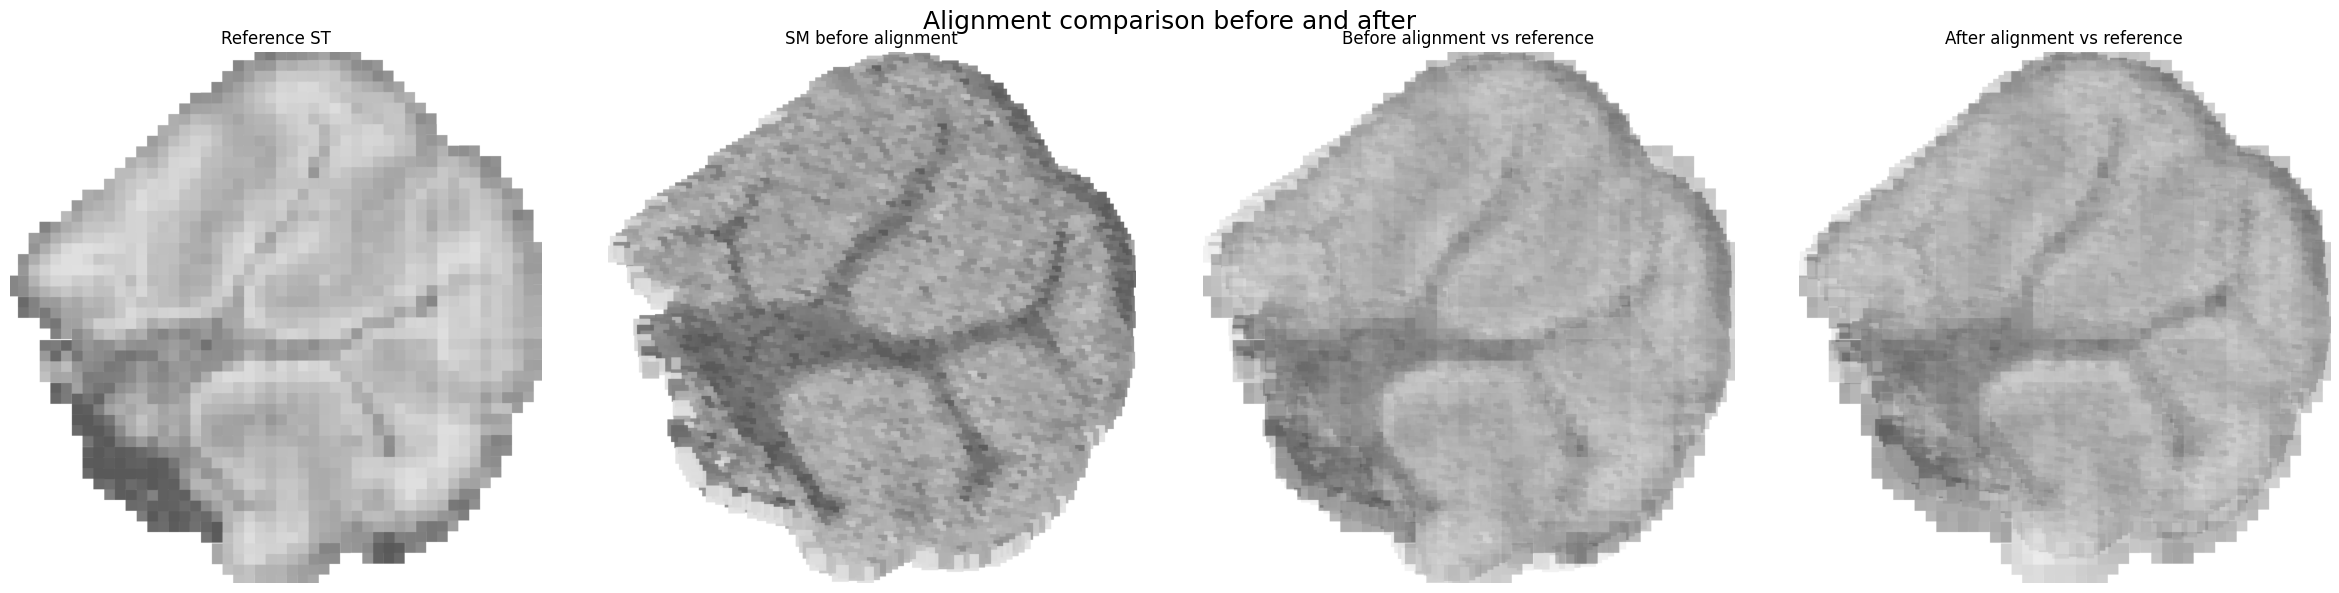

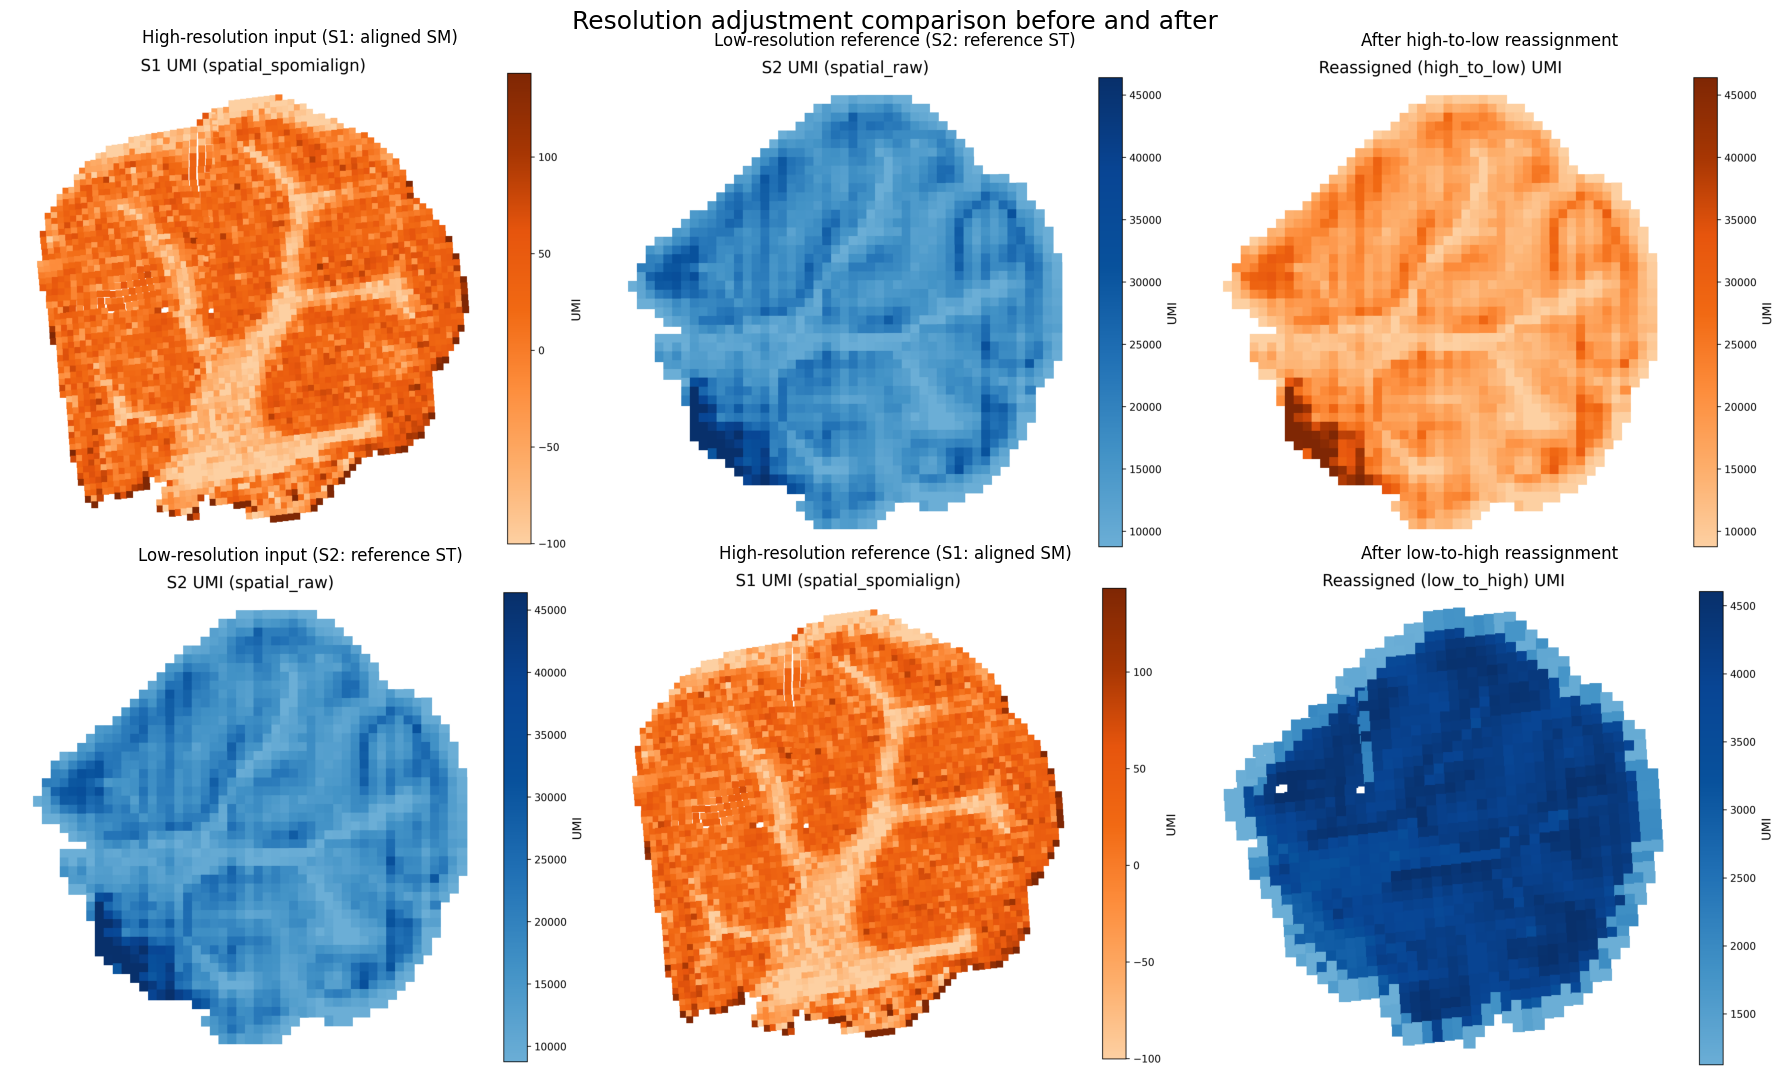

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
_show_bgr(axes[0], Gen_img1_path, "Reference ST")
_show_bgr(axes[1], Gen_img2_path, "SM before alignment")
_show_bgr(axes[2], before_overlay_path, "Before alignment vs reference")
_show_bgr(axes[3], after_overlay_path, "After alignment vs reference")
fig.suptitle("Alignment comparison before and after", fontsize=18)
plt.tight_layout()
plt.show()

high_low_low_name = high_to_low_meta["low_res_name"]
high_low_high_name = high_to_low_meta["high_res_name"]
low_high_low_name = low_to_high_meta["low_res_name"]
low_high_high_name = low_to_high_meta["high_res_name"]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
_show_bgr(
    axes[0, 0],
    high_to_low_plot_dir / f"{high_low_high_name}_umi.png",
    f"High-resolution input ({_label_for_dataset(high_low_high_name)})",
)
_show_bgr(
    axes[0, 1],
    high_to_low_plot_dir / f"{high_low_low_name}_umi.png",
    f"Low-resolution reference ({_label_for_dataset(high_low_low_name)})",
)
_show_bgr(
    axes[0, 2],
    high_to_low_plot_dir / "reassigned_high_to_low_umi.png",
    "After high-to-low reassignment",
)

_show_bgr(
    axes[1, 0],
    low_to_high_plot_dir / f"{low_high_low_name}_umi.png",
    f"Low-resolution input ({_label_for_dataset(low_high_low_name)})",
)
_show_bgr(
    axes[1, 1],
    low_to_high_plot_dir / f"{low_high_high_name}_umi.png",
    f"High-resolution reference ({_label_for_dataset(low_high_high_name)})",
)
_show_bgr(
    axes[1, 2],
    low_to_high_plot_dir / "reassigned_low_to_high_umi.png",
    "After low-to-high reassignment",
)

fig.suptitle("Resolution adjustment comparison before and after", fontsize=18)
plt.tight_layout()
plt.show()
